In [18]:
# ============================================================
# Bike-Sharing Demand Analysis & Promotion Strategy
# Raaghul Nataraj Kannan
# Arizona State University — MS Data Science
# ============================================================

In [19]:
!pip install shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from scipy import stats
import shap
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded.")

Libraries loaded.


In [21]:
from google.colab import files
print("Please upload hour.csv")
files.upload()

Please upload hour.csv


Saving hour.csv to hour.csv


{'hour.csv': b'instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt\r\n1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0,3,13,16\r\n2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.8,0,8,32,40\r\n3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.8,0,5,27,32\r\n4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0,3,10,13\r\n5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0,0,1,1\r\n6,2011-01-01,1,0,1,5,0,6,0,2,0.24,0.2576,0.75,0.0896,0,1,1\r\n7,2011-01-01,1,0,1,6,0,6,0,1,0.22,0.2727,0.8,0,2,0,2\r\n8,2011-01-01,1,0,1,7,0,6,0,1,0.2,0.2576,0.86,0,1,2,3\r\n9,2011-01-01,1,0,1,8,0,6,0,1,0.24,0.2879,0.75,0,1,7,8\r\n10,2011-01-01,1,0,1,9,0,6,0,1,0.32,0.3485,0.76,0,8,6,14\r\n11,2011-01-01,1,0,1,10,0,6,0,1,0.38,0.3939,0.76,0.2537,12,24,36\r\n12,2011-01-01,1,0,1,11,0,6,0,1,0.36,0.3333,0.81,0.2836,26,30,56\r\n13,2011-01-01,1,0,1,12,0,6,0,1,0.42,0.4242,0.77,0.2836,29,55,84\r\n14,2011-01-01,1,0,1,13,0,6,0,2,0.46,0.4545,0.72,0.2985,47,47,94\r\n15,2011-01-01,1

In [20]:
df = pd.read_csv('hour.csv')

print("Shape:", df.shape)
print("\nHead:")
print(df.head(10))
print("\nColumn names:", df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())
print("\nDescriptive statistics:")
print(df.describe())

Shape: (17379, 17)

Head:
   instant      dteday  season  yr  mnth  hr  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1   0        0        6           0   
1        2  2011-01-01       1   0     1   1        0        6           0   
2        3  2011-01-01       1   0     1   2        0        6           0   
3        4  2011-01-01       1   0     1   3        0        6           0   
4        5  2011-01-01       1   0     1   4        0        6           0   
5        6  2011-01-01       1   0     1   5        0        6           0   
6        7  2011-01-01       1   0     1   6        0        6           0   
7        8  2011-01-01       1   0     1   7        0        6           0   
8        9  2011-01-01       1   0     1   8        0        6           0   
9       10  2011-01-01       1   0     1   9        0        6           0   

   weathersit  temp   atemp   hum  windspeed  casual  registered  cnt  
0           1  0.24  0.2879  0.81     0.000

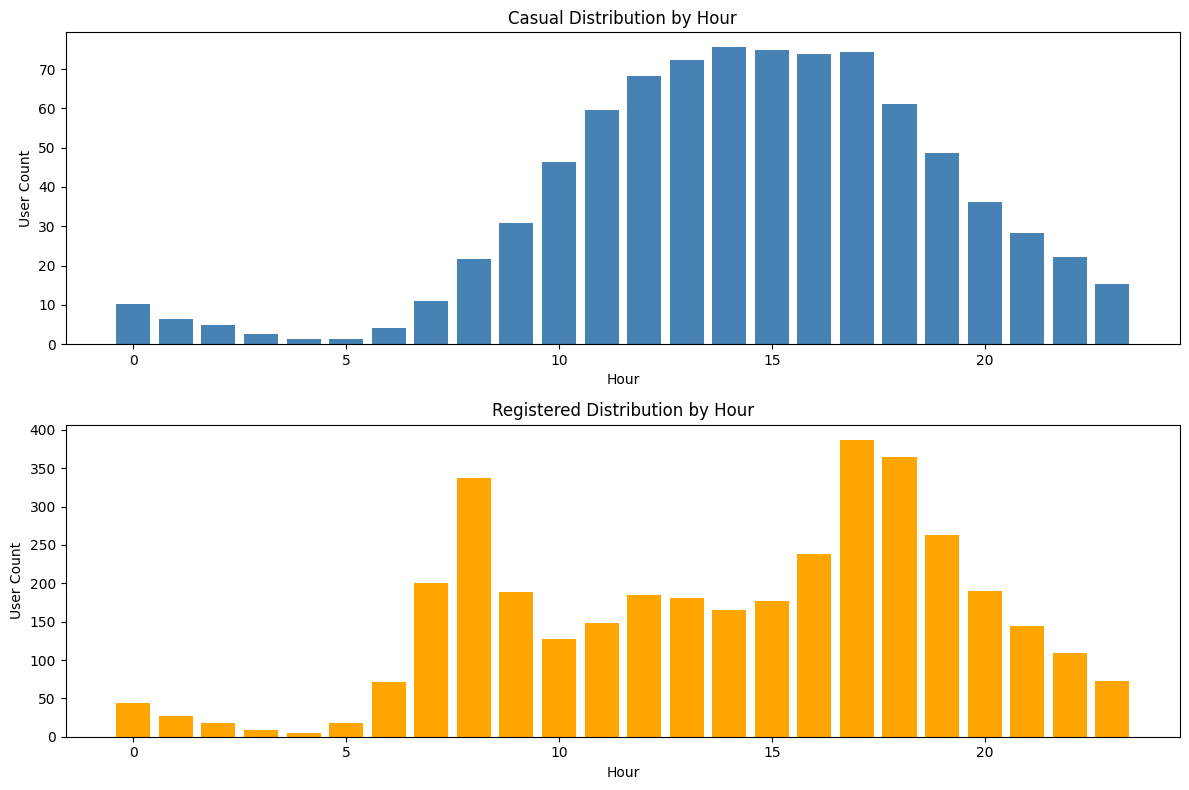

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

casual_by_hour = df.groupby('hr')['casual'].mean()
registered_by_hour = df.groupby('hr')['registered'].mean()

axes[0].bar(casual_by_hour.index, casual_by_hour.values, color='steelblue')
axes[0].set_title('Casual Distribution by Hour')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('User Count')

axes[1].bar(registered_by_hour.index, registered_by_hour.values, color='orange')
axes[1].set_title('Registered Distribution by Hour')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('User Count')

plt.tight_layout()
plt.show()

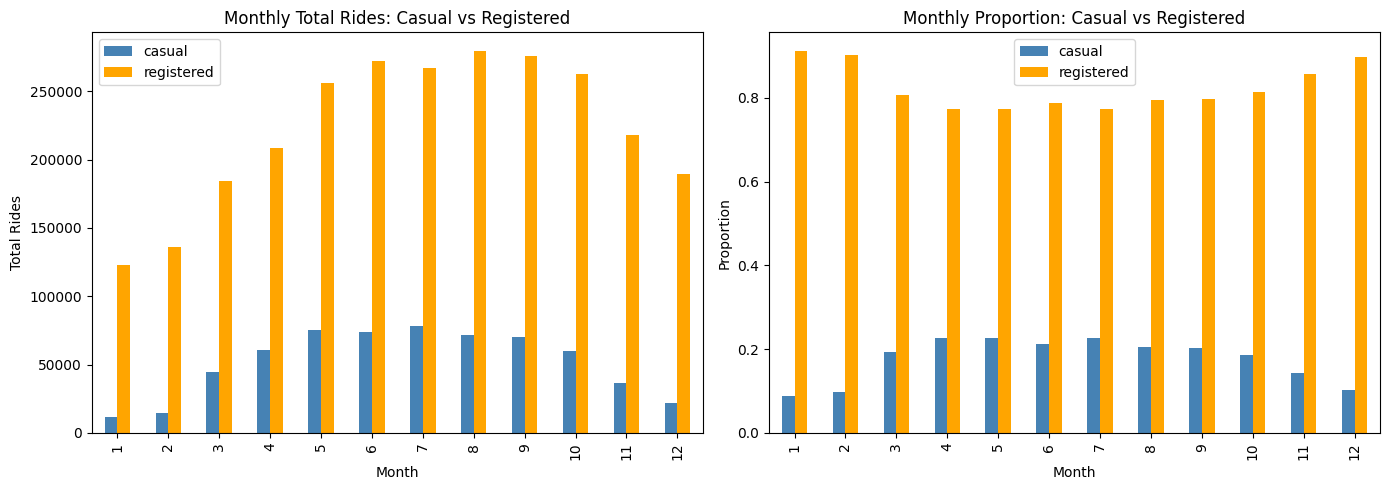

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

monthly = df.groupby('mnth')[['casual', 'registered', 'cnt']].sum()

# Monthly total rides
monthly[['casual', 'registered']].plot(kind='bar', ax=axes[0],
                                        color=['steelblue', 'orange'])
axes[0].set_title('Monthly Total Rides: Casual vs Registered')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Total Rides')

# Monthly proportion
monthly_prop = monthly[['casual', 'registered']].div(monthly['cnt'], axis=0)
monthly_prop.plot(kind='bar', ax=axes[1], color=['steelblue', 'orange'])
axes[1].set_title('Monthly Proportion: Casual vs Registered')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Proportion')

plt.tight_layout()
plt.show()

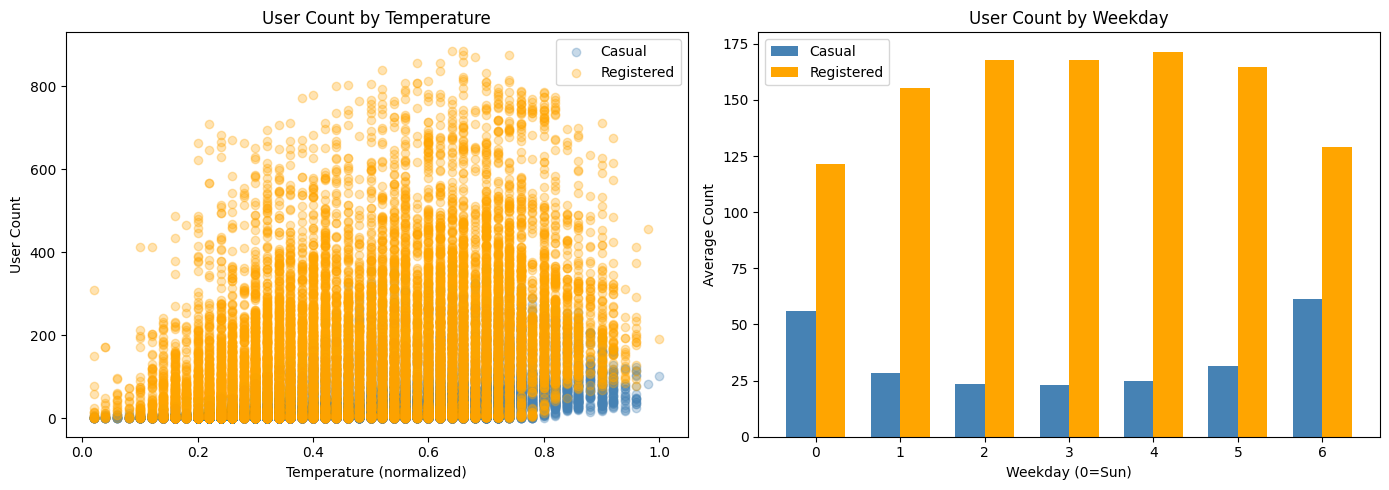

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Temperature vs ridership
axes[0].scatter(df['temp'], df['casual'], alpha=0.3, color='steelblue', label='Casual')
axes[0].scatter(df['temp'], df['registered'], alpha=0.3, color='orange', label='Registered')
axes[0].set_title('User Count by Temperature')
axes[0].set_xlabel('Temperature (normalized)')
axes[0].set_ylabel('User Count')
axes[0].legend()

# Weekday distribution
weekday_casual = df.groupby('weekday')['casual'].mean()
weekday_registered = df.groupby('weekday')['registered'].mean()
x = np.arange(7)
width = 0.35
axes[1].bar(x - width/2, weekday_casual, width, color='steelblue', label='Casual')
axes[1].bar(x + width/2, weekday_registered, width, color='orange', label='Registered')
axes[1].set_title('User Count by Weekday')
axes[1].set_xlabel('Weekday (0=Sun)')
axes[1].set_ylabel('Average Count')
axes[1].legend()

plt.tight_layout()
plt.show()

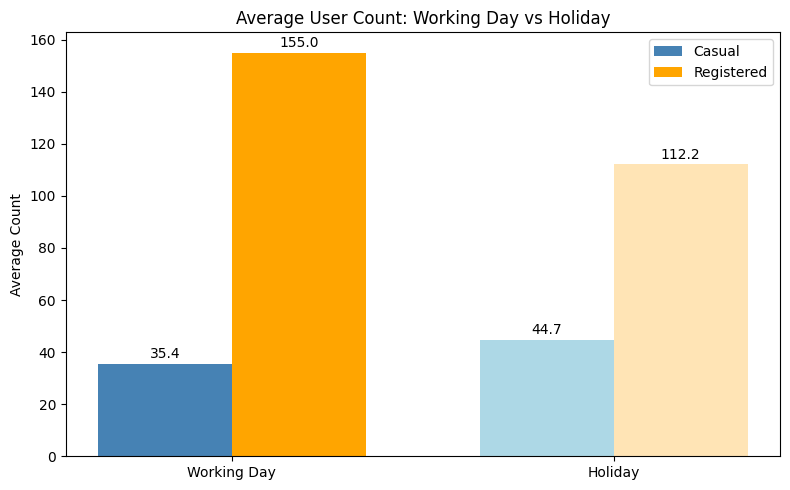

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

holiday_casual = df.groupby('holiday')['casual'].mean()
holiday_registered = df.groupby('holiday')['registered'].mean()

x = np.arange(2)
width = 0.35
bars1 = ax.bar(x - width/2, holiday_casual, width,
               color=['steelblue', 'lightblue'], label='Casual')
bars2 = ax.bar(x + width/2, holiday_registered, width,
               color=['orange', 'moccasin'], label='Registered')

ax.set_title('Average User Count: Working Day vs Holiday')
ax.set_xticks(x)
ax.set_xticklabels(['Working Day', 'Holiday'])
ax.set_ylabel('Average Count')
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.1f}', ha='center', va='bottom')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.1f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

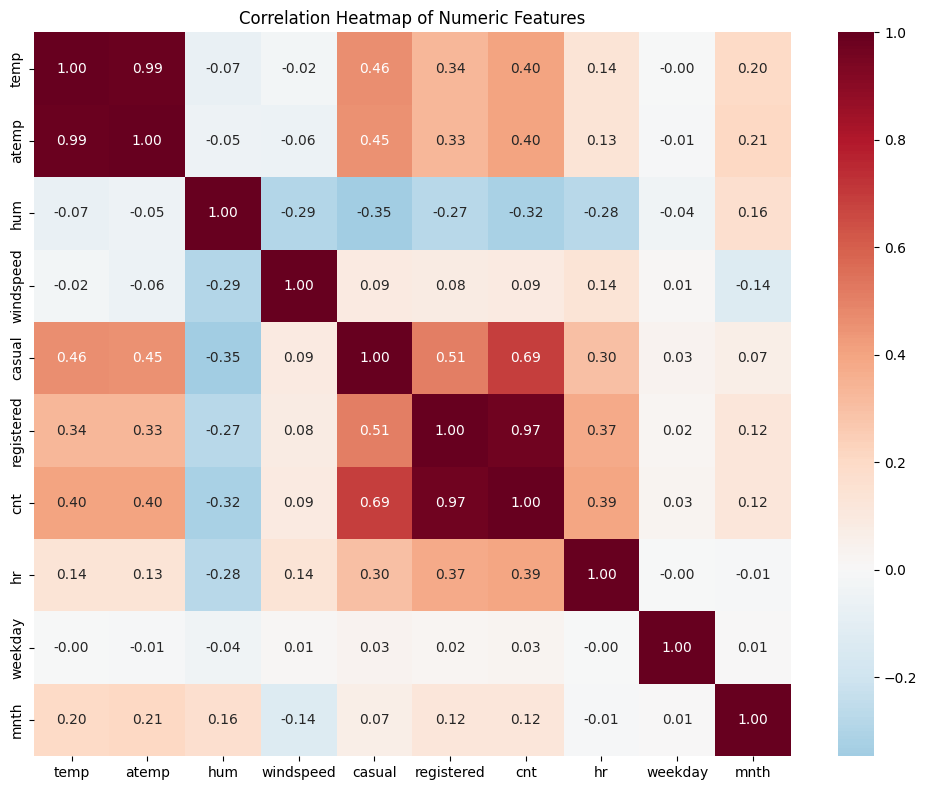

In [ ]:
numeric_cols = ['temp', 'atemp', 'hum', 'windspeed',
                'casual', 'registered', 'cnt', 'hr', 'weekday', 'mnth']

plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f',
            cmap='RdBu_r', center=0)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

In [ ]:
features = ['hr', 'weekday', 'mnth', 'season', 'holiday',
            'workingday', 'weathersit', 'temp', 'atemp',
            'hum', 'windspeed', 'yr']

X = df[features]
y_casual = df['casual']
y_registered = df['registered']
y_total = df['cnt']

print("Features:", features)
print("Dataset shape:", X.shape)

Features: ['hr', 'weekday', 'mnth', 'season', 'holiday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'yr']
Dataset shape: (17379, 12)


In [ ]:
X_train, X_test, yc_train, yc_test = train_test_split(
    X, y_casual, test_size=0.2, random_state=42)
_, _, yr_train, yr_test = train_test_split(
    X, y_registered, test_size=0.2, random_state=42)
_, _, yt_train, yt_test = train_test_split(
    X, y_total, test_size=0.2, random_state=42)

print(f"Train size: {X_train.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

Train size: 13903
Test size: 3476


In [ ]:
# Casual model
rf_casual = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_casual.fit(X_train, yc_train)

# Registered model
rf_registered = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_registered.fit(X_train, yr_train)

# Total model
rf_total = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_total.fit(X_train, yt_train)

print("Models trained.")

Models trained.


In [ ]:
models = {
    'Casual': (rf_casual, yc_train, yc_test),
    'Registered': (rf_registered, yr_train, yr_test),
    'Total': (rf_total, yt_train, yt_test)
}

print(f"{'Model':<12} {'Train R²':<12} {'Test R²':<12}")
print("-" * 36)

for name, (model, y_train, y_test) in models.items():
    train_r2 = r2_score(y_train, model.predict(X_train))
    test_r2 = r2_score(y_test, model.predict(X_test))
    print(f"{name:<12} {train_r2:<12.2f} {test_r2:<12.2f}")

Model        Train R²     Test R²     
------------------------------------
Casual       0.97         0.91        
Registered   0.99         0.94        
Total        0.99         0.94        


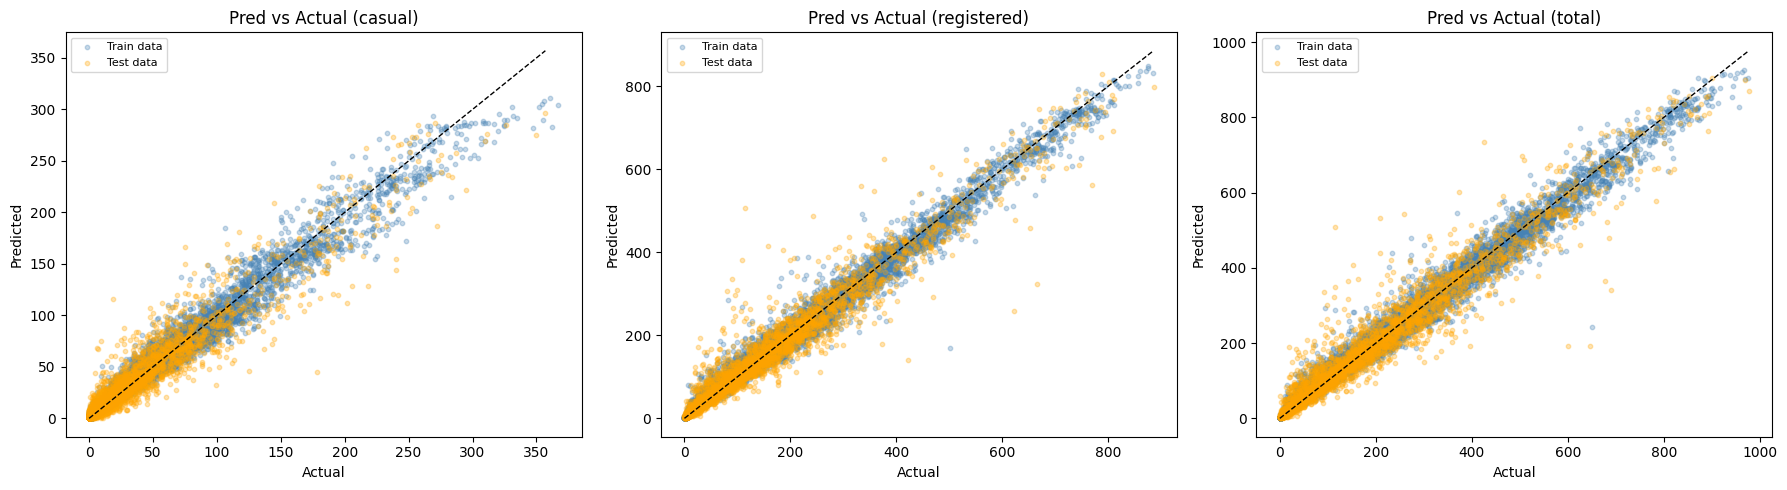

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, (model, y_train, y_test)) in zip(axes, models.items()):
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    ax.scatter(y_train, y_pred_train, alpha=0.3, color='steelblue',
               label='Train data', s=10)
    ax.scatter(y_test, y_pred_test, alpha=0.3, color='orange',
               label='Test data', s=10)

    max_val = max(y_test.max(), y_pred_test.max())
    ax.plot([0, max_val], [0, max_val], 'k--', linewidth=1)

    ax.set_title(f'Pred vs Actual ({name.lower()})')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

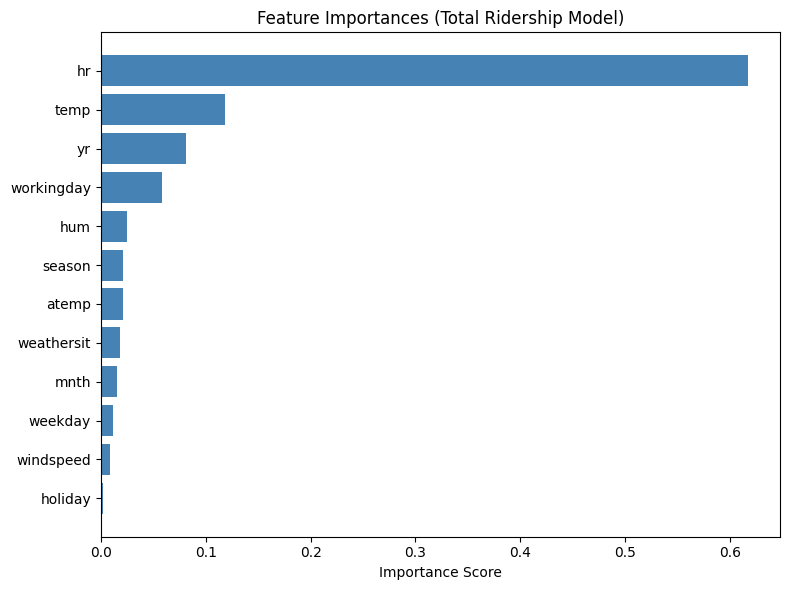

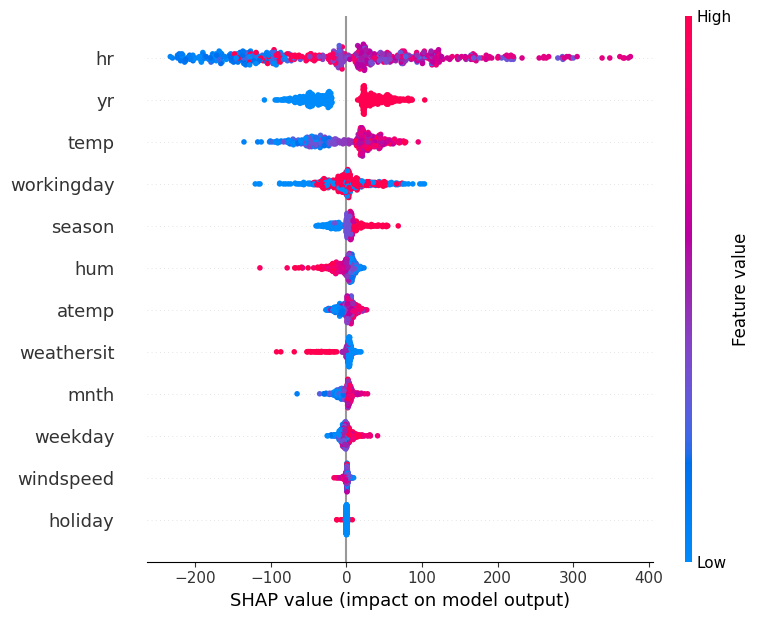

In [15]:
# Feature importance bar chart
importances = rf_total.feature_importances_
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
plt.title('Feature Importances (Total Ridership Model)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# SHAP values
explainer = shap.TreeExplainer(rf_total)
shap_values = explainer.shap_values(X_test[:500])
shap.summary_plot(shap_values, X_test[:500], feature_names=features)

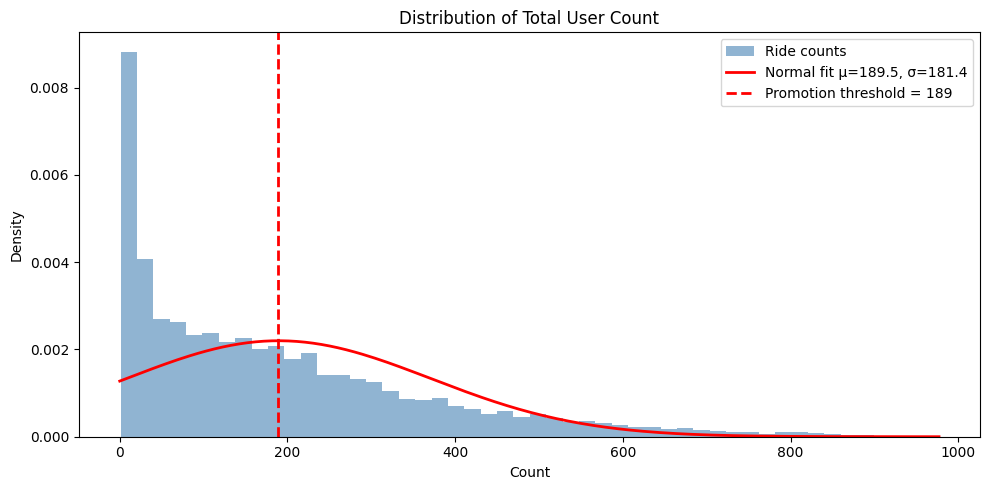

Fitted mean (µ): 189.5
True mean: 189.5
Promotion triggers when predicted count < 189


In [16]:
from scipy.stats import norm

plt.figure(figsize=(10, 5))
plt.hist(df['cnt'], bins=50, density=True, alpha=0.6,
         color='steelblue', label='Ride counts')

mu, std = norm.fit(df['cnt'])
x = np.linspace(0, df['cnt'].max(), 200)
plt.plot(x, norm.pdf(x, mu, std), 'r-', linewidth=2,
         label=f'Normal fit µ={mu:.1f}, σ={std:.1f}')

threshold = 189
plt.axvline(x=threshold, color='red', linestyle='--', linewidth=2,
            label=f'Promotion threshold = {threshold}')

plt.title('Distribution of Total User Count')
plt.xlabel('Count')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Fitted mean (µ): {mu:.1f}")
print(f"True mean: {df['cnt'].mean():.1f}")
print(f"Promotion triggers when predicted count < {threshold}")

In [17]:
strategy = {
    'Fall/Winter': 'Ride 5 consecutive days → win $50 Amazon gift card',
    'Off-peak (casual)': '5% off during 9PM–6AM weekdays',
    'Off-peak (registered)': '10% off off-hours, 5% off 11AM–2PM',
    'Holidays': '5% off for rides over 30 minutes',
    'Cold days': '15% off with code WARMUP',
    'Referrals': 'First 3 trips free for new registered users'
}

print("=" * 60)
print("CONTEXT-AWARE PROMOTION STRATEGY")
print("=" * 60)
for scenario, promo in strategy.items():
    print(f"\n{scenario}:")
    print(f"  → {promo}")
print("=" * 60)

CONTEXT-AWARE PROMOTION STRATEGY

Fall/Winter:
  → Ride 5 consecutive days → win $50 Amazon gift card

Off-peak (casual):
  → 5% off during 9PM–6AM weekdays

Off-peak (registered):
  → 10% off off-hours, 5% off 11AM–2PM

Holidays:
  → 5% off for rides over 30 minutes

Cold days:
  → 15% off with code WARMUP

Referrals:
  → First 3 trips free for new registered users
